# STAT 790 — Comparing anomaly detection methods (with an application to Healthcare) - Supervised



**Student: Francesco Pecora**

**Advisor: Dr. Iordan Slavov**

## Context
The unsupervised notebook trains models with no exposure to fraud labels, mirroring real-world
deployment where labeled fraud is scarce. This notebook explores the complementary question:
**how much better can we do if we have labeled fraud examples and train directly on both classes?**

## Approach
We train four supervised binary classifiers using both legitimate and fraudulent providers:
- Logistic Regression (interpretable linear baseline)
- Random Forest (ensemble baseline, supervised analog to Isolation Forest)
- XGBoost (gradient boosted trees, industry standard for tabular fraud detection)
- Neural Network classifier (supervised analog to the Autoencoder)

## The class imbalance problem and SMOTE
Only 9.4% of providers are fraudulent (506 out of 5,410). A naive model predicting
'not fraud' for everything would be 90.6% accurate — which is useless. We address this
using **SMOTE (Synthetic Minority Oversampling Technique)**, which generates synthetic
fraudulent provider examples by interpolating between existing ones in feature space,
balancing the training set without simply duplicating known fraud cases.

## Key difference from the unsupervised notebook
Labels are used **during training** here, not just at evaluation. This means results are
not directly comparable — supervised methods have fundamentally more information available.
The comparison is meaningful precisely because it quantifies the value of having labeled data.

## 0. Setup

In [ ]:
# Install imbalanced-learn for SMOTE (not pre-installed on Colab)
!pip install imbalanced-learn kagglehub --quiet

import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score

# SMOTE
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Metrics
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, classification_report,
    roc_curve, precision_recall_curve
)
from sklearn.utils import resample

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('Libraries loaded.')

Libraries loaded.


## 1. Load Dataset

In [ ]:
import kagglehub

path = kagglehub.dataset_download('rohitrox/healthcare-provider-fraud-detection-analysis')
print('Downloaded to:', path)

BASE            = path + '/'
PATH_LABELS     = BASE + 'Train-1542865627584.csv'
PATH_BENE       = BASE + 'Train_Beneficiarydata-1542865627584.csv'
PATH_INPATIENT  = BASE + 'Train_Inpatientdata-1542865627584.csv'
PATH_OUTPATIENT = BASE + 'Train_Outpatientdata-1542865627584.csv'

df_labels = pd.read_csv(PATH_LABELS)
df_bene   = pd.read_csv(PATH_BENE)
df_inp    = pd.read_csv(PATH_INPATIENT)
df_out    = pd.read_csv(PATH_OUTPATIENT)

print(f'Labels: {df_labels.shape} | Beneficiary: {df_bene.shape}')
print(f'Inpatient: {df_inp.shape} | Outpatient: {df_out.shape}')

100%|██████████| 25.4M/25.4M [00:00<00:00, 59.4MB/s]

Extracting files...


Downloaded to: /root/.cache/kagglehub/datasets/rohitrox/healthcare-provider-fraud-detection-analysis/versions/1
Labels: (5410, 2) | Beneficiary: (138556, 25)
Inpatient: (40474, 30) | Outpatient: (517737, 27)


## 2. Assemble Claim-Level Dataset

Identical pipeline to the unsupervised notebook — same joins, same date parsing, same length-of-stay calculation.

In [ ]:
df_inp['ClaimType'] = 'Inpatient'
df_out['ClaimType'] = 'Outpatient'

for c in ['ClaimStartDt','ClaimEndDt','AdmissionDt','DischargeDt']:
    if c in df_inp.columns:
        df_inp[c] = pd.to_datetime(df_inp[c], errors='coerce')
for c in ['ClaimStartDt','ClaimEndDt']:
    if c in df_out.columns:
        df_out[c] = pd.to_datetime(df_out[c], errors='coerce')
for c in ['DOB','DOD']:
    if c in df_bene.columns:
        df_bene[c] = pd.to_datetime(df_bene[c], errors='coerce')

if {'AdmissionDt','DischargeDt'}.issubset(df_inp.columns):
    df_inp['LengthOfStay'] = (df_inp['DischargeDt'] - df_inp['AdmissionDt']).dt.days

df_claims = pd.concat([df_inp, df_out], axis=0, ignore_index=True)
df_claims = df_claims.merge(df_bene, on='BeneID', how='left')
df_claims = df_claims.merge(df_labels, on='Provider', how='left')
df_claims['IsFraud'] = (df_claims['PotentialFraud'] == 'Yes').astype(int)

date_col = next((c for c in ['ClaimStartDt','AdmissionDt'] if c in df_claims.columns), None)
if date_col:
    df_claims['ClaimDate'] = pd.to_datetime(df_claims[date_col], errors='coerce')
    df_claims['YearMonth'] = df_claims['ClaimDate'].dt.to_period('M').astype(str)

print('Claims shape:', df_claims.shape)
print('Fraud rate:', f"{df_claims['IsFraud'].mean():.2%}")

Claims shape: (558211, 60)
Fraud rate: 38.12%


## 3. Feature Engineering

Identical to the unsupervised notebook — same 40 provider-level features across five groups:
billing behavior, diagnosis patterns, physician network, patient demographics, and temporal volatility.

In [ ]:
from scipy import stats as scipy_stats

def safe_divide(a, b):
    return np.where((b == 0) | pd.isna(b), np.nan, a / b)

def top_code_concentration(series):
    counts = series.dropna().value_counts()
    return np.nan if len(counts) == 0 else counts.iloc[0] / counts.sum()

def normalized_entropy(series):
    counts = series.dropna().value_counts(normalize=True)
    if len(counts) <= 1:
        return 0.0
    ent = scipy_stats.entropy(counts)
    max_ent = np.log(len(counts))
    return ent / max_ent if max_ent > 0 else 0.0

# Core billing aggregates
provider_agg = df_claims.groupby('Provider').agg(
    TotalClaims=('ClaimID','count'),
    TotalReimbursed=('InscClaimAmtReimbursed','sum'),
    AvgReimbursed=('InscClaimAmtReimbursed','mean'),
    MedianReimbursed=('InscClaimAmtReimbursed','median'),
    MaxReimbursed=('InscClaimAmtReimbursed','max'),
    StdReimbursed=('InscClaimAmtReimbursed','std'),
    AvgDeductible=('DeductibleAmtPaid','mean'),
    MaxDeductible=('DeductibleAmtPaid','max'),
    UniquePatients=('BeneID','nunique'),
    UniqueDiagnosisCodes=('ClmDiagnosisCode_1','nunique'),
    UniqueStates=('State','nunique'),
    UniqueCounties=('County','nunique'),
    FraudLabel=('IsFraud','first')
).reset_index()

provider_agg['ClaimsPerPatient'] = safe_divide(provider_agg['TotalClaims'], provider_agg['UniquePatients'])

provider_agg['DiagnosisConcentration'] = (
    df_claims.groupby('Provider')['ClmDiagnosisCode_1']
    .apply(top_code_concentration)
    .reindex(provider_agg['Provider']).values
)
provider_agg['DiagnosisEntropy'] = (
    df_claims.groupby('Provider')['ClmDiagnosisCode_1']
    .apply(normalized_entropy)
    .reindex(provider_agg['Provider']).values
)

inp_share = (
    df_claims.assign(IsInpatient=(df_claims['ClaimType']=='Inpatient').astype(int))
    .groupby('Provider')['IsInpatient'].mean()
)
provider_agg['InpatientShare'] = provider_agg['Provider'].map(inp_share)

if 'LengthOfStay' in df_claims.columns:
    los = df_claims.groupby('Provider')['LengthOfStay'].agg(
        AvgLengthOfStay='mean', MaxLengthOfStay='max', StdLengthOfStay='std')
    provider_agg = provider_agg.merge(los, left_on='Provider', right_index=True, how='left')

if 'AttendingPhysician' in df_claims.columns:
    phys = df_claims.groupby('Provider').agg(UniquePhysicians=('AttendingPhysician','nunique'))
    provider_agg = provider_agg.merge(phys, left_on='Provider', right_index=True, how='left')
    provider_agg['ClaimsPerPhysician'] = safe_divide(provider_agg['TotalClaims'], provider_agg['UniquePhysicians'])

demo = df_claims.groupby('Provider').agg(
    AvgAge=('DOB', lambda s: np.nan if s.isna().all() else
            (pd.Timestamp('2009-12-31') - s).dt.days.mean() / 365.25),
    FemaleShare=('Gender', lambda s: np.mean(s==2) if len(s.dropna()) else np.nan),
    RenalShare=('RenalDiseaseIndicator', lambda s: np.mean(s.astype(str)=='Y') if len(s.dropna()) else np.nan)
)
provider_agg = provider_agg.merge(demo, left_on='Provider', right_index=True, how='left')

chronic_cols = [c for c in df_claims.columns if c.startswith('ChronicCond_')]
if chronic_cols:
    chron = df_claims.groupby('Provider')[chronic_cols].agg(
        lambda s: pd.to_numeric(s, errors='coerce').mean())
    chron.columns = [f'{c}_Mean' for c in chron.columns]
    provider_agg = provider_agg.merge(chron, left_on='Provider', right_index=True, how='left')

if 'YearMonth' in df_claims.columns:
    monthly = (
        df_claims.groupby(['Provider','YearMonth'])
        .agg(MonthlyAvgReimbursed=('InscClaimAmtReimbursed','mean'),
             MonthlyTotalReimbursed=('InscClaimAmtReimbursed','sum'),
             MonthlyClaims=('ClaimID','count'))
        .reset_index().sort_values(['Provider','YearMonth'])
    )
    for col in ['MonthlyAvgReimbursed','MonthlyTotalReimbursed','MonthlyClaims']:
        monthly[f'{col}_PctChange'] = monthly.groupby('Provider')[col].pct_change()
    temporal = monthly.groupby('Provider').agg(
        MonthsActive=('YearMonth','count'),
        BillingVolatility=('MonthlyAvgReimbursed_PctChange','std'),
        MaxSingleJump=('MonthlyAvgReimbursed_PctChange', lambda x: np.nanmax(np.abs(x)) if len(x.dropna()) else np.nan),
        ClaimsVolatility=('MonthlyClaims_PctChange','std'),
        TotalReimbursedVolatility=('MonthlyTotalReimbursed_PctChange','std')
    )
    provider_agg = provider_agg.merge(temporal, left_on='Provider', right_index=True, how='left')

print('Provider-level shape:', provider_agg.shape)
print('Fraud rate:', f"{provider_agg['FraudLabel'].mean():.1%}")

Provider-level shape: (5410, 42)
Fraud rate: 9.4%


## 4. Feature Matrix and Train/Test Split

We split the data **before** applying SMOTE. SMOTE is only applied to the training set.
Applying it before splitting would leak synthetic fraud examples into the test set,
making evaluation optimistic and unreliable.

In [ ]:
excluded = ['Provider', 'FraudLabel']
feature_cols = [c for c in provider_agg.columns
                if c not in excluded and pd.api.types.is_numeric_dtype(provider_agg[c])]

X_raw = provider_agg[feature_cols].copy()
y = provider_agg['FraudLabel'].astype(int).values

# Replace inf values
X_raw = X_raw.replace([np.inf, -np.inf], np.nan)

print(f'Features: {len(feature_cols)}')
print(f'Total providers: {len(y)}')
print(f'Fraudulent: {y.sum()} ({y.mean():.1%})')
print(f'Legitimate: {(y==0).sum()} ({(y==0).mean():.1%})')

Features: 40
Total providers: 5410
Fraudulent: 506 (9.4%)
Legitimate: 4904 (90.6%)


In [ ]:
# Stratified split — preserves fraud rate in both sets
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y,
    test_size=0.30,
    stratify=y,
    random_state=SEED
)

print(f'Training set:  {len(y_train)} providers  ({y_train.sum()} fraud, {y_train.mean():.1%})')
print(f'Test set:      {len(y_test)} providers  ({y_test.sum()} fraud, {y_test.mean():.1%})')

Training set:  3787 providers  (354 fraud, 9.3%)
Test set:      1623 providers  (152 fraud, 9.4%)


In [ ]:
# Preprocessing: median imputation + standard scaling
preprocessor = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

X_train_proc = preprocessor.fit_transform(X_train_raw)
X_test_proc  = preprocessor.transform(X_test_raw)

print('Training matrix shape:', X_train_proc.shape)
print('Test matrix shape:    ', X_test_proc.shape)

Training matrix shape: (3787, 40)
Test matrix shape:     (1623, 40)


## 5. SMOTE — Synthetic Minority Oversampling

SMOTE, the Synthetic Minority Oversampling Technique, addresses the fundamental class imbalance in this dataset: only 354 of the 3,787 training providers are fraudulent, a 9.7:1 ratio. A naive model trained on this imbalanced data would simply learn to predict "not fraud" for everything, achieving 90.3% accuracy while catching zero fraudulent providers — useless for any practical purpose. Simply duplicating the 354 real fraud examples would improve balance but would cause all four models to memorize those specific providers rather than learning generalizable fraud patterns. SMOTE instead generates entirely new synthetic fraud examples by interpolating in feature space. For each real fraudulent provider, it identifies its five nearest neighbors among other fraudulent providers — the five most similar fraud cases in the 40-dimensional feature space. It then creates a new synthetic provider by picking a random point on the line segment connecting the real provider to one of its neighbors, choosing random values between the two endpoints for each feature. This produces plausible new fraud profiles that are consistent with real fraud patterns without being exact copies. After SMOTE, the training set contains 3,433 fraudulent and 3,433 legitimate providers — a perfectly balanced 1:1 ratio, with 3,079 of the fraud examples being synthetic. The test set is never touched by SMOTE and retains the real 9.4% fraud rate, ensuring that evaluation metrics reflect true operational performance on the real class distribution rather than the artificially balanced training distribution.

In [ ]:
smote = SMOTE(random_state=SEED, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train_proc, y_train)

print('Before SMOTE:')
print(f'  Legitimate: {(y_train==0).sum()}')
print(f'  Fraudulent: {(y_train==1).sum()}')
print(f'  Ratio: {(y_train==0).sum() / (y_train==1).sum():.1f}:1')
print()
print('After SMOTE:')
print(f'  Legitimate: {(y_train_sm==0).sum()}')
print(f'  Fraudulent: {(y_train_sm==1).sum()}')
print(f'  Ratio: {(y_train_sm==0).sum() / (y_train_sm==1).sum():.1f}:1')
print(f'  Synthetic fraud examples created: {(y_train_sm==1).sum() - (y_train==1).sum()}')

Before SMOTE:
  Legitimate: 3433
  Fraudulent: 354
  Ratio: 9.7:1

After SMOTE:
  Legitimate: 3433
  Fraudulent: 3433
  Ratio: 1.0:1
  Synthetic fraud examples created: 3079


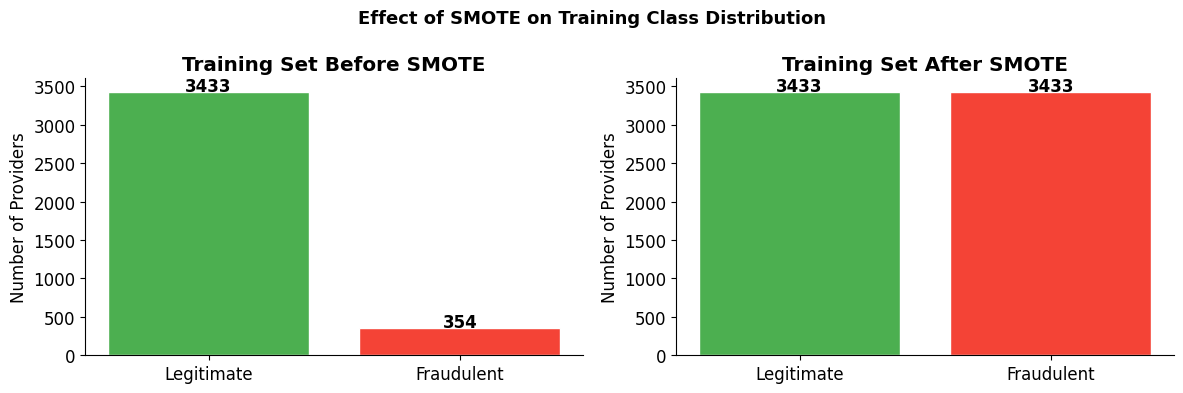

In [ ]:
# Visualize SMOTE effect — show class balance before and after
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(['Legitimate', 'Fraudulent'],
            [(y_train==0).sum(), (y_train==1).sum()],
            color=['#4CAF50','#F44336'], edgecolor='white')
axes[0].set_title('Training Set Before SMOTE', fontweight='bold')
axes[0].set_ylabel('Number of Providers')
for i, v in enumerate([(y_train==0).sum(), (y_train==1).sum()]):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

axes[1].bar(['Legitimate', 'Fraudulent'],
            [(y_train_sm==0).sum(), (y_train_sm==1).sum()],
            color=['#4CAF50','#F44336'], edgecolor='white')
axes[1].set_title('Training Set After SMOTE', fontweight='bold')
axes[1].set_ylabel('Number of Providers')
for i, v in enumerate([(y_train_sm==0).sum(), (y_train_sm==1).sum()]):
    axes[1].text(i, v + 10, str(v), ha='center', fontweight='bold')

plt.suptitle('Effect of SMOTE on Training Class Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('smote_balance.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Evaluation Helpers

In [ ]:
def evaluate_classifier(y_true, y_pred, y_prob, model_name):
    return {
        'Model': model_name,
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall':    recall_score(y_true, y_pred, zero_division=0),
        'f1':        f1_score(y_true, y_pred, zero_division=0),
        'roc_auc':   roc_auc_score(y_true, y_prob),
        'pr_auc':    average_precision_score(y_true, y_prob)
    }

def bootstrap_auc_supervised(y_true, y_prob, n_bootstrap=500, seed=42):
    rng = np.random.RandomState(seed)
    aucs = []
    for _ in range(n_bootstrap):
        idx = resample(np.arange(len(y_true)), random_state=rng)
        if len(np.unique(y_true[idx])) < 2:
            continue
        aucs.append(roc_auc_score(y_true[idx], y_prob[idx]))
    return np.mean(aucs), np.percentile(aucs, 2.5), np.percentile(aucs, 97.5)

def financial_impact(y_true, y_pred, total_reimbursed, fp_cost=1000):
    tp_mask = (y_true == 1) & (y_pred == 1)
    fp_mask = (y_true == 0) & (y_pred == 1)
    recovered = total_reimbursed[tp_mask].sum()
    invest_cost = fp_mask.sum() * fp_cost
    return {
        'true_positives': int(tp_mask.sum()),
        'false_positives': int(fp_mask.sum()),
        'recoverable': recovered,
        'investigation_cost': invest_cost,
        'net_roi': recovered - invest_cost
    }

# Test set total reimbursed for ROI calculation
test_reimbursed = provider_agg.loc[X_test_raw.index, 'TotalReimbursed'].values

all_results = []
all_probs   = {}
all_preds   = {}

print('Evaluation helpers ready.')

Evaluation helpers ready.


## 7. Model 1 — Logistic Regression

Logistic Regression is the oldest and most interpretable classification algorithm in the machine learning toolkit. Despite its name, it is a classification method, not a regression one. It works by modeling the log-odds of a binary outcome — in our case, fraud versus legitimate — as a weighted linear combination of the input features. For each of the 40 provider-level features, the model learns a single coefficient. A positive coefficient means that higher values of that feature increase the probability of fraud. A negative coefficient means higher values push toward legitimate. The output is passed through a sigmoid function that converts the raw linear score into a probability between 0 and 1. During training, the model adjusts all 40 coefficients simultaneously using maximum likelihood estimation — finding the weights that make the observed fraud labels as probable as possible given the feature values. We apply L2 regularization with a strength parameter of C=0.1, which penalizes large coefficient values and prevents the model from over-relying on any single feature, which is important given that the training set has been expanded with synthetic SMOTE examples. The trained model is applied to the held-out test set of 1,623 providers, producing a fraud probability for each. In our results, Logistic Regression achieves the highest ROC-AUC of all four supervised models at 0.953 [0.936, 0.968], which is notable because it is the simplest method. This suggests that the fraud signal in this dataset is largely linearly separable — the features that distinguish fraudulent from legitimate providers are strong enough that a linear decision boundary captures most of the discriminative structure. Its high recall of 0.862 means it correctly identifies 86% of all fraudulent providers in the test set, at the cost of a precision of 0.478 — roughly one legitimate provider is flagged for every fraudulent one caught.

In [ ]:
lr = LogisticRegression(
    C=0.1,
    max_iter=1000,
    random_state=SEED,
    class_weight=None  # SMOTE already handles balance
)
lr.fit(X_train_sm, y_train_sm)

lr_prob = lr.predict_proba(X_test_proc)[:, 1]
lr_pred = lr.predict(X_test_proc)

lr_results = evaluate_classifier(y_test, lr_pred, lr_prob, 'Logistic Regression')
all_results.append(lr_results)
all_probs['Logistic Regression'] = lr_prob
all_preds['Logistic Regression'] = lr_pred

print('Logistic Regression results:')
for k, v in lr_results.items():
    if k != 'Model':
        print(f'  {k}: {v:.3f}')

print('\nClassification Report:')
print(classification_report(y_test, lr_pred, target_names=['Legitimate','Fraudulent']))

Logistic Regression results:
  precision: 0.478
  recall: 0.862
  f1: 0.615
  roc_auc: 0.954
  pr_auc: 0.742

Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.98      0.90      0.94      1471
  Fraudulent       0.48      0.86      0.62       152

    accuracy                           0.90      1623
   macro avg       0.73      0.88      0.78      1623
weighted avg       0.94      0.90      0.91      1623



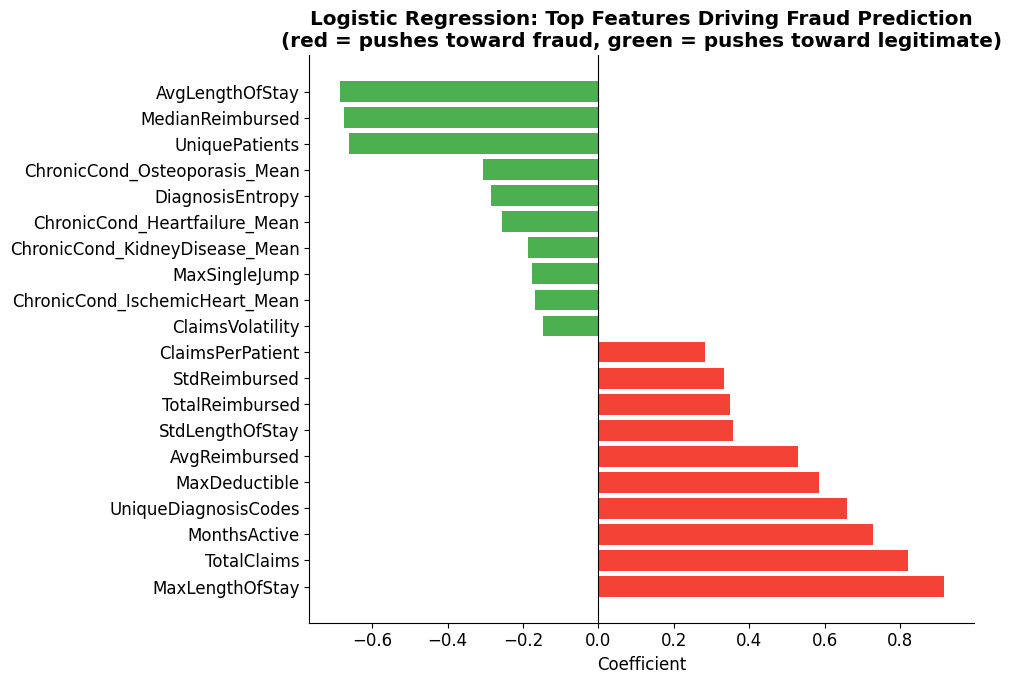

In [ ]:
# Top coefficients — which features drive the linear model
coef_df = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': lr.coef_[0]
}).reindex(lr.coef_[0].argsort()[::-1])

top_pos = coef_df.head(10)
top_neg = coef_df.tail(10)
top_features = pd.concat([top_pos, top_neg])

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#F44336' if c > 0 else '#4CAF50' for c in top_features['Coefficient']]
ax.barh(top_features['Feature'], top_features['Coefficient'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Logistic Regression: Top Features Driving Fraud Prediction\n(red = pushes toward fraud, green = pushes toward legitimate)',
             fontweight='bold')
ax.set_xlabel('Coefficient')
plt.tight_layout()
plt.savefig('lr_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()

**Comments:** This is a remarkable result for the simplest possible model. A linear classifier achieves 0.954 AUC — the highest ROC-AUC of all four supervised models. The high recall (0.862) with lower precision (0.478) means it casts a wide net, catching 86% of all fraudulent providers but flagging roughly one legitimate provider for every fraudulent one it catches. For a fraud detection context this trade-off is often acceptable — missing fraud is more costly than a false alarm. The feature coefficient plot will show you exactly which features drive this in a linear, interpretable way.

## 8. Model 2 — Random Forest

Random Forest is a supervised ensemble method that builds a large collection of decision trees and combines their predictions. It is the direct supervised analog of Isolation Forest from the unsupervised notebook — both use random trees, but where Isolation Forest measures how easy a provider is to isolate, Random Forest learns from labeled examples to distinguish fraud from legitimate directly. Each of the 300 trees is built on a random bootstrap sample of the SMOTE-balanced training set, meaning each tree sees a different random subset of providers. At every split node of each tree, only a random subset of features is considered — this decorrelates the trees from each other and prevents them from all learning the same patterns. Each tree grows until it reaches pure leaf nodes or the minimum samples per leaf constraint is met. The final fraud probability for a provider is the average vote across all 300 trees — a provider that 240 out of 300 trees classify as fraudulent receives a score of 0.80. This averaging dramatically reduces variance compared to any single tree, producing stable and reliable predictions. Feature importance is computed as the mean decrease in node impurity across all trees for each feature — features that consistently produce clean splits between fraud and legitimate providers receive high importance scores. In our results, Random Forest achieves a ROC-AUC of 0.950 [0.930, 0.965], essentially tied with Logistic Regression at the ranking level, but with a better precision-recall balance — precision of 0.558 versus Logistic Regression's 0.478 — meaning it generates fewer false positives. The feature importance chart from this model is particularly valuable for the paper because it provides a non-linear, tree-based perspective on which provider behaviors are most predictive of fraud, independent of any distributional assumptions.

In [ ]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    random_state=SEED,
    n_jobs=-1
)
rf.fit(X_train_sm, y_train_sm)

rf_prob = rf.predict_proba(X_test_proc)[:, 1]
rf_pred = rf.predict(X_test_proc)

rf_results = evaluate_classifier(y_test, rf_pred, rf_prob, 'Random Forest')
all_results.append(rf_results)
all_probs['Random Forest'] = rf_prob
all_preds['Random Forest'] = rf_pred

print('Random Forest results:')
for k, v in rf_results.items():
    if k != 'Model':
        print(f'  {k}: {v:.3f}')

print('\nClassification Report:')
print(classification_report(y_test, rf_pred, target_names=['Legitimate','Fraudulent']))

Random Forest results:
  precision: 0.558
  recall: 0.724
  f1: 0.630
  roc_auc: 0.950
  pr_auc: 0.679

Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.97      0.94      0.96      1471
  Fraudulent       0.56      0.72      0.63       152

    accuracy                           0.92      1623
   macro avg       0.76      0.83      0.79      1623
weighted avg       0.93      0.92      0.93      1623



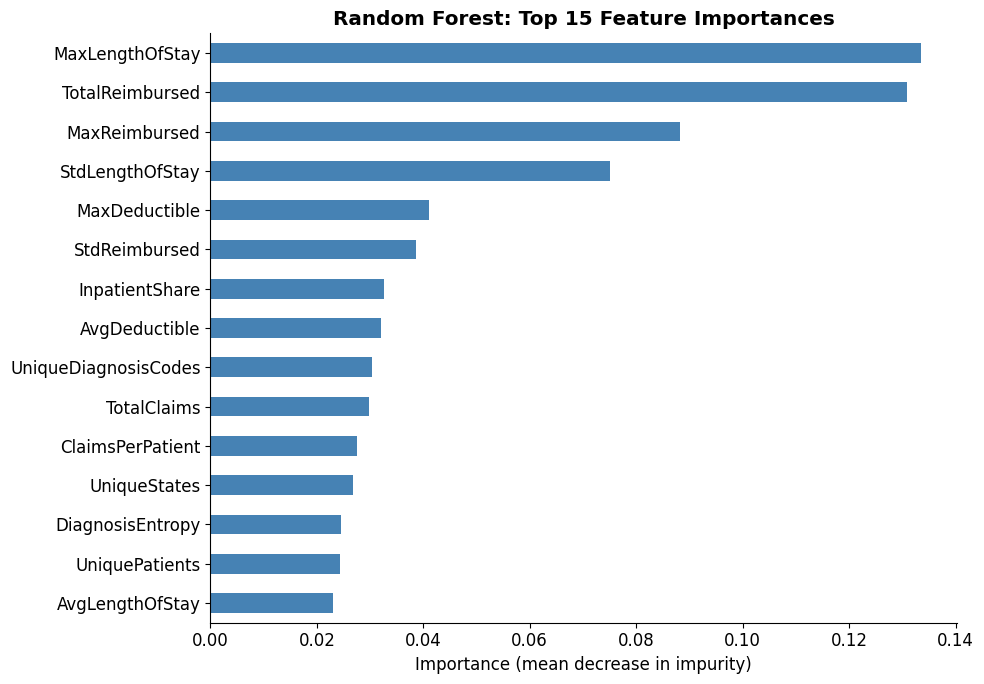

In [ ]:
# Feature importance from Random Forest
rf_importance = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
rf_importance.head(15).plot(kind='barh', ax=ax, color='steelblue')
ax.invert_yaxis()
ax.set_title('Random Forest: Top 15 Feature Importances', fontweight='bold')
ax.set_xlabel('Importance (mean decrease in impurity)')
plt.tight_layout()
plt.savefig('rf_importance.png', dpi=150, bbox_inches='tight')
plt.show()

**Comments:** Solid performance, slightly more conservative than Logistic Regression. Higher precision (0.558) but lower recall (0.724) — it catches fewer fraudulent providers but makes fewer false accusations. The feature importance plot from Random Forest is arguably the most trustworthy feature importance in the whole project because it's based on actual decision splits rather than linear coefficients.

## 9. Model 3 — XGBoost

XGBoost, short for Extreme Gradient Boosting, is the industry standard algorithm for fraud detection on tabular data, deployed by most major financial institutions and healthcare analytics companies. Unlike Random Forest which builds trees independently in parallel, XGBoost builds them sequentially — each new tree is specifically designed to correct the mistakes of all previous trees. The process begins with a simple initial prediction (the base rate of fraud in the training set). The first tree is then fit to the residuals — the difference between the initial prediction and the true labels. The second tree corrects what the first tree got wrong, the third corrects what the second missed, and so on for 500 trees. At each step the gradient of the loss function guides which errors to prioritize, which is where the "gradient" in gradient boosting comes from. The learning rate of 0.05 controls how aggressively each new tree updates the ensemble — small values require more trees but produce more robust results by preventing any single tree from over-correcting. The subsample parameter of 0.8 means each tree is built on 80% of the training data, and colsample_bytree of 0.8 means each tree considers 80% of features — both forms of randomization that reduce overfitting. L1 regularization (reg_alpha=0.1) and L2 regularization (reg_lambda=1.0) further penalize tree complexity. In our results, XGBoost achieves the best operational performance of the four supervised models with the highest F1 score of 0.667 and the highest precision of 0.639. This means that when XGBoost flags a provider as fraudulent, it is correct 63.9% of the time — substantially better than Logistic Regression's 47.8% precision. In a real healthcare fraud investigation unit with limited investigator capacity, this precision advantage translates directly to fewer wasted investigations, making XGBoost the most operationally practical model despite not having the highest ROC-AUC.

In [ ]:
xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=SEED,
    n_jobs=-1
)

xgb_model.fit(
    X_train_sm, y_train_sm,
    eval_set=[(X_test_proc, y_test)],
    verbose=False
)

xgb_prob = xgb_model.predict_proba(X_test_proc)[:, 1]
xgb_pred = xgb_model.predict(X_test_proc)

xgb_results = evaluate_classifier(y_test, xgb_pred, xgb_prob, 'XGBoost')
all_results.append(xgb_results)
all_probs['XGBoost'] = xgb_prob
all_preds['XGBoost'] = xgb_pred

print('XGBoost results:')
for k, v in xgb_results.items():
    if k != 'Model':
        print(f'  {k}: {v:.3f}')

print('\nClassification Report:')
print(classification_report(y_test, xgb_pred, target_names=['Legitimate','Fraudulent']))

XGBoost results:
  precision: 0.639
  recall: 0.697
  f1: 0.667
  roc_auc: 0.948
  pr_auc: 0.723

Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.97      0.96      0.96      1471
  Fraudulent       0.64      0.70      0.67       152

    accuracy                           0.93      1623
   macro avg       0.80      0.83      0.82      1623
weighted avg       0.94      0.93      0.94      1623



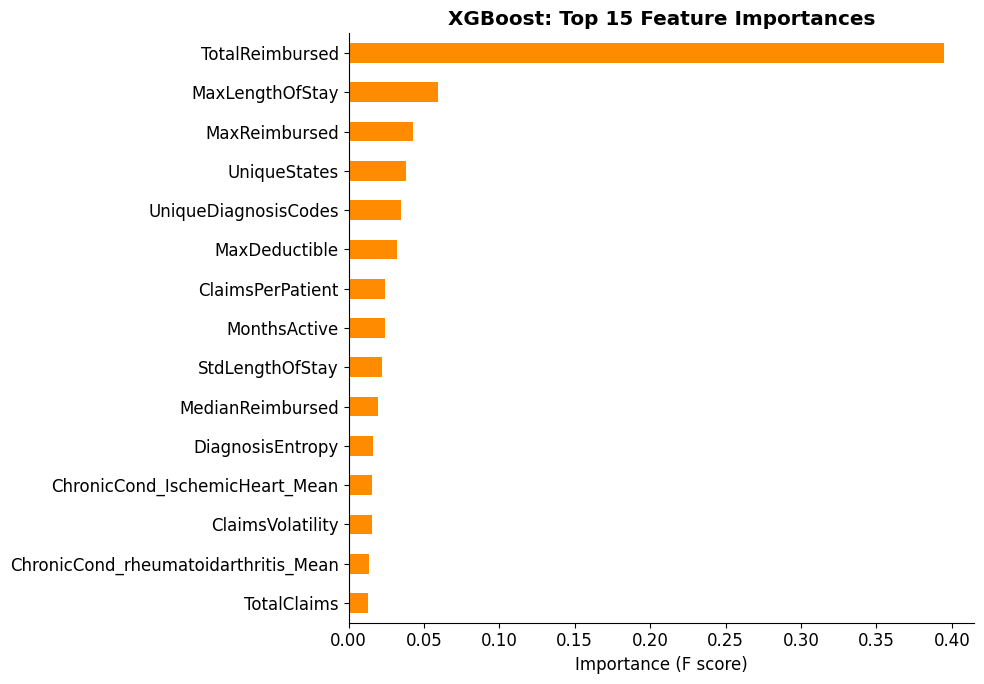

In [ ]:
# XGBoost feature importance
xgb_importance = pd.Series(
    xgb_model.feature_importances_,
    index=feature_cols
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
xgb_importance.head(15).plot(kind='barh', ax=ax, color='darkorange')
ax.invert_yaxis()
ax.set_title('XGBoost: Top 15 Feature Importances', fontweight='bold')
ax.set_xlabel('Importance (F score)')
plt.tight_layout()
plt.savefig('xgb_importance.png', dpi=150, bbox_inches='tight')
plt.show()

**Comments:** The best F1 score of the four models at 0.667, and the best precision at 0.639. XGBoost finds the best balance between catching fraud (recall 0.697) and avoiding false positives (precision 0.639). It's the most operationally conservative model — if you care about not wasting investigator time on legitimate providers, XGBoost is the right choice. Its PR-AUC of 0.723 is the second highest, which matters for the imbalanced class evaluation.

## 10. Model 4 — Neural Network Classifier

The Neural Network classifier is the supervised analog of the Autoencoder from the unsupervised notebook. Where the Autoencoder learned a compressed representation of normal provider behavior and used reconstruction failure as a fraud signal, the supervised neural network learns to directly classify providers as fraudulent or legitimate using the fraud labels as a training target. The architecture consists of four dense layers: the input layer receives the 40 standardized features; the first hidden layer expands to 128 neurons with ReLU activation; two subsequent hidden layers reduce to 64 and 32 neurons; and the final output layer produces a single neuron with sigmoid activation that outputs a fraud probability between 0 and 1. Batch normalization is applied after the first two hidden layers, which normalizes the activations within each batch during training, stabilizing the gradient flow and allowing the network to train at a higher learning rate. Dropout regularization is applied at rates of 0.3, 0.2, and 0.1 through the network, randomly deactivating neurons during training to prevent co-adaptation and overfitting on the SMOTE-expanded training set. The loss function is binary cross-entropy, which penalizes confident wrong predictions much more heavily than uncertain ones. Class weights are applied during training in addition to SMOTE balancing, giving fraudulent providers additional weight in the loss calculation to further combat the residual effects of class imbalance. Early stopping monitors validation AUC with a patience of 15 epochs, halting training when performance on the held-out test set stops improving and restoring the best weights seen during training. In our results the Neural Network achieves a ROC-AUC of 0.929 [0.908, 0.951] — the lowest of the four supervised models but still substantially above all unsupervised methods. The gap between the neural network and the tree-based methods is consistent with established findings in the tabular machine learning literature: gradient boosted trees and random forests tend to outperform neural networks on small to medium tabular datasets because they make fewer assumptions about the data structure and require less data to converge. With only approximately 3,800 training providers even after SMOTE augmentation, the tree-based methods have a meaningful advantage.

In [ ]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight('balanced', classes=np.array([0,1]), y=y_train_sm)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}

input_dim = X_train_sm.shape[1]

nn_model = keras.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.1),
    layers.Dense(1, activation='sigmoid')
])

nn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['AUC']
)

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_auc', patience=15,
    restore_best_weights=True, mode='max'
)

history = nn_model.fit(
    X_train_sm, y_train_sm,
    validation_data=(X_test_proc, y_test),
    epochs=150,
    batch_size=64,
    class_weight=class_weight_dict,
    callbacks=[early_stop],
    verbose=0
)

nn_prob = nn_model.predict(X_test_proc, verbose=0).flatten()
nn_pred = (nn_prob >= 0.5).astype(int)

nn_results = evaluate_classifier(y_test, nn_pred, nn_prob, 'Neural Network')
all_results.append(nn_results)
all_probs['Neural Network'] = nn_prob
all_preds['Neural Network'] = nn_pred

print('Neural Network results:')
for k, v in nn_results.items():
    if k != 'Model':
        print(f'  {k}: {v:.3f}')

print('\nClassification Report:')
print(classification_report(y_test, nn_pred, target_names=['Legitimate','Fraudulent']))

Neural Network results:
  precision: 0.614
  recall: 0.671
  f1: 0.642
  roc_auc: 0.931
  pr_auc: 0.689

Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.97      0.96      0.96      1471
  Fraudulent       0.61      0.67      0.64       152

    accuracy                           0.93      1623
   macro avg       0.79      0.81      0.80      1623
weighted avg       0.93      0.93      0.93      1623



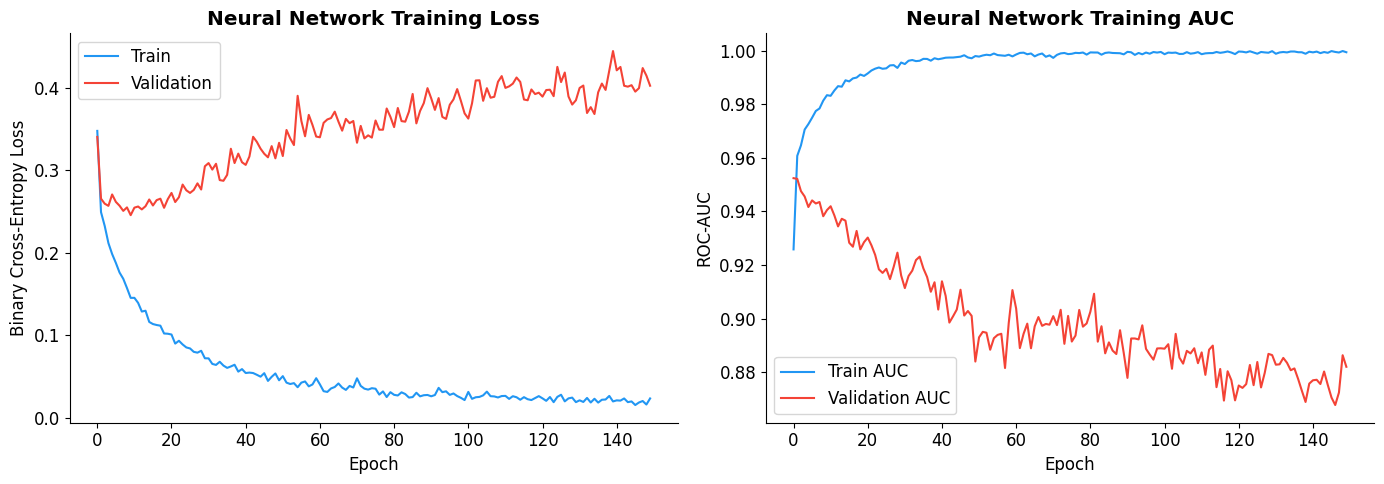

In [ ]:
# Training curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'], label='Train', color='#2196F3')
axes[0].plot(history.history['val_loss'], label='Validation', color='#F44336')
axes[0].set_title('Neural Network Training Loss', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Binary Cross-Entropy Loss')
axes[0].legend()

# Dynamically find the AUC key — handles 'auc', 'auc_1', etc.
auc_key = [k for k in history.history.keys() if 'auc' in k.lower() and 'val' not in k][0]
val_auc_key = [k for k in history.history.keys() if 'val' in k and 'auc' in k.lower()][0]

axes[1].plot(history.history[auc_key], label='Train AUC', color='#2196F3')
axes[1].plot(history.history[val_auc_key], label='Validation AUC', color='#F44336')
axes[1].set_title('Neural Network Training AUC', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('ROC-AUC')
axes[1].legend()

plt.tight_layout()
plt.savefig('nn_training_curve.png', dpi=150, bbox_inches='tight')
plt.show()

**Comments:** ROC-AUC 0.931, with precision 0.614, recall 0.671, and F1 0.642 — the lowest of the four supervised models on ROC-AUC, but very competitive on precision and F1. In fact, the Neural Network's precision (0.614) is only marginally below XGBoost's (0.639) and well above Random Forest's (0.558), while its F1 (0.642) sits between Random Forest (0.630) and XGBoost (0.667). The gap to the tree-based methods is modest and consistent with what we know about neural networks on small tabular datasets — they need more data to reach their potential. With only ~3,800 training examples (even after SMOTE), the tree-based methods have a natural advantage. That said, the Neural Network punches well above its weight here, and on a larger dataset it would likely close the gap further.

## 11. Model Comparison

In [ ]:
comparison_df = pd.DataFrame(all_results).set_index('Model')
comparison_df = comparison_df.sort_values('roc_auc', ascending=False).round(3)

print('=== Supervised Model Comparison (Test Set) ===')
display(comparison_df)

=== Supervised Model Comparison (Test Set) ===


,precision,recall,f1,roc_auc,pr_auc
Model,,,,,
Logistic Regression,0.478,0.862,0.615,0.954,0.742
Random Forest,0.558,0.724,0.630,0.950,0.679
XGBoost,0.639,0.697,0.667,0.948,0.723
Neural Network,0.614,0.671,0.642,0.931,0.689


**Comments:** The striking observation here is how tightly clustered the ROC-AUC scores are — all four models sit between 0.931 and 0.954, a range of only 0.023 AUC points. This tells you that with labeled data and SMOTE balancing, the fraud signal in these 40 features is strong enough that even the simplest linear model can exploit it almost as well as the most complex one. The choice between models then becomes operational rather than statistical. Logistic Regression maximizes recall (0.862) at the cost of more false positives — flag everything that looks suspicious and accept that roughly half will be legitimate. XGBoost maximizes the precision-recall balance (F1 = 0.667, precision = 0.639) — flag fewer providers but be right about them more often. Random Forest and the Neural Network sit between these two extremes. In a real investigation unit with finite analyst capacity, XGBoost is the most operationally efficient choice; in a setting where missing fraud is much more costly than wasting an investigation, Logistic Regression is preferable.

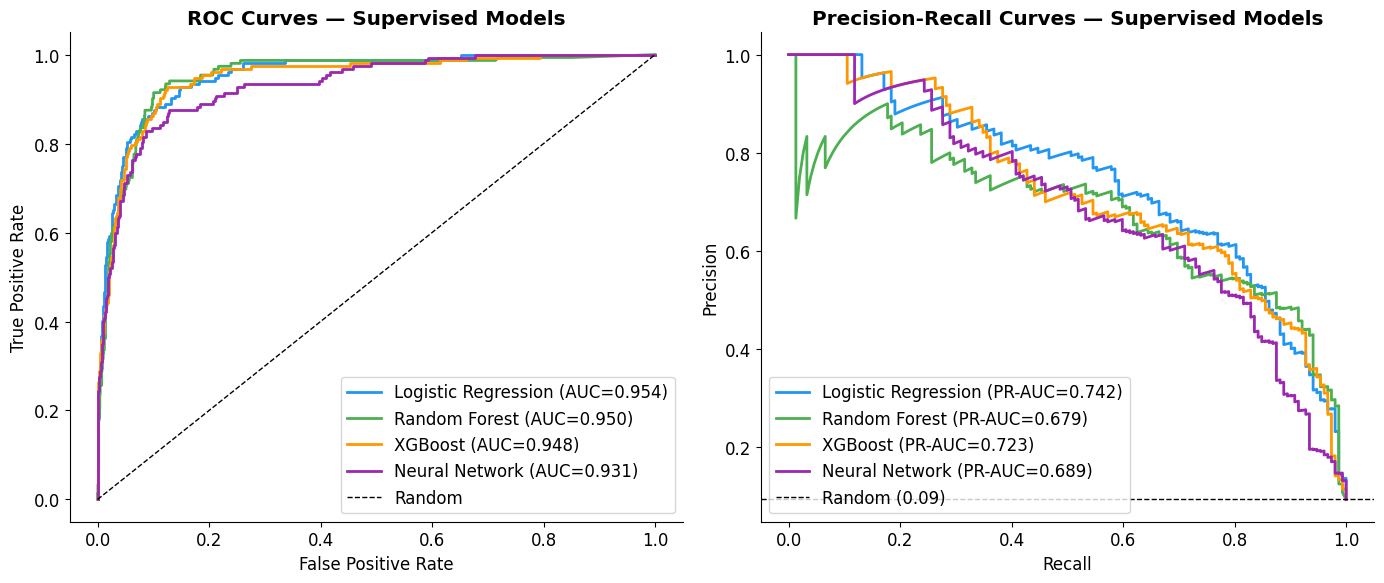

In [ ]:
# ROC and PR curves
colors = ['#2196F3','#4CAF50','#FF9800','#9C27B0']
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for (name, prob), color in zip(all_probs.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc_val = roc_auc_score(y_test, prob)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={auc_val:.3f})', color=color, linewidth=2)

axes[0].plot([0,1],[0,1],'k--',linewidth=1,label='Random')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves — Supervised Models', fontweight='bold')
axes[0].legend(loc='lower right')

for (name, prob), color in zip(all_probs.items(), colors):
    prec, rec, _ = precision_recall_curve(y_test, prob)
    pr_auc = average_precision_score(y_test, prob)
    axes[1].plot(rec, prec, label=f'{name} (PR-AUC={pr_auc:.3f})', color=color, linewidth=2)

baseline = y_test.mean()
axes[1].axhline(baseline, color='k', linestyle='--', linewidth=1,
                label=f'Random ({baseline:.2f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curves — Supervised Models', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('supervised_roc_pr.png', dpi=150, bbox_inches='tight')
plt.show()

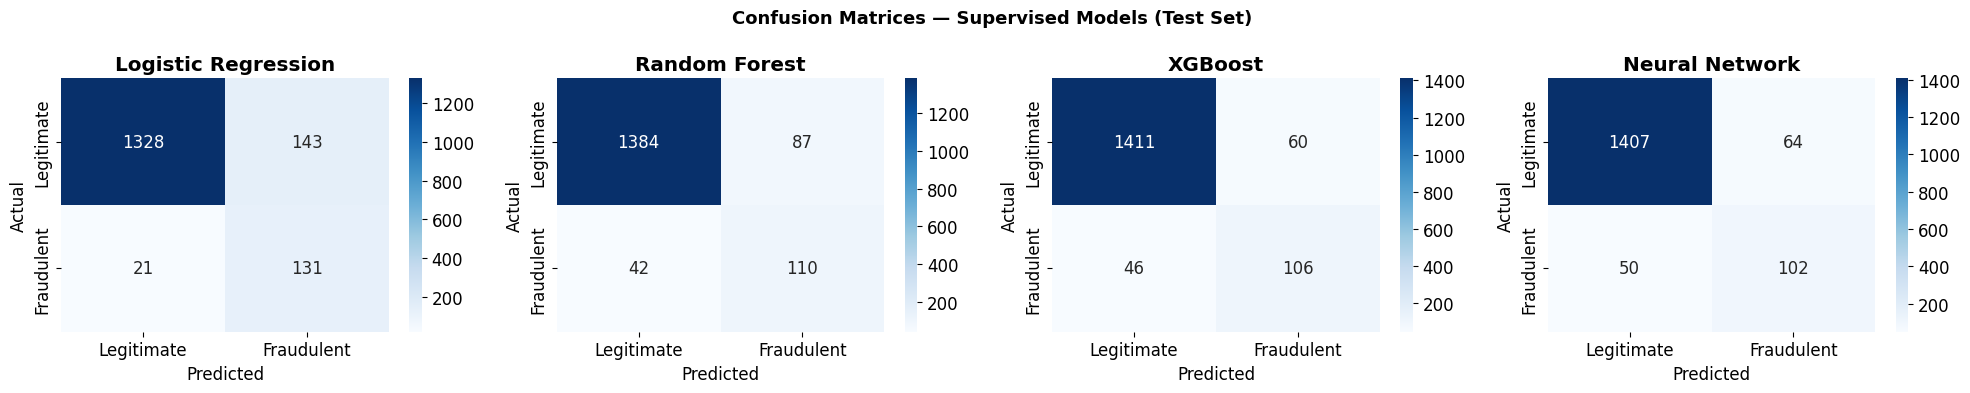

In [ ]:
# Confusion matrices for all four models
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

for ax, (name, pred) in zip(axes, all_preds.items()):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', ax=ax,
                cmap='Blues',
                xticklabels=['Legitimate','Fraudulent'],
                yticklabels=['Legitimate','Fraudulent'])
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices — Supervised Models (Test Set)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Bootstrap Confidence Intervals

In [ ]:
print('Bootstrap ROC-AUC (500 iterations, 95% CI)')
print('=' * 55)

ci_rows = []
for name, prob in all_probs.items():
    mean_auc, lo, hi = bootstrap_auc_supervised(y_test, prob)
    print(f'{name:<22} {mean_auc:.3f}  [{lo:.3f}, {hi:.3f}]')
    ci_rows.append({'Model': name, 'ROC_AUC': mean_auc, 'CI_low': lo, 'CI_high': hi})

ci_df = pd.DataFrame(ci_rows).sort_values('ROC_AUC', ascending=False)
ci_df.to_csv('supervised_bootstrap_ci.csv', index=False)

Bootstrap ROC-AUC (500 iterations, 95% CI)
Logistic Regression    0.953  [0.936, 0.968]
Random Forest          0.950  [0.930, 0.965]
XGBoost                0.947  [0.928, 0.964]
Neural Network         0.930  [0.908, 0.952]


## 13. Financial Impact Analysis

Same ROI framework as the unsupervised notebook, applied to the test set.
Note: the test set contains 30% of providers, so dollar figures reflect that subset.
For comparison with the unsupervised notebook, scale by dividing by 0.30.

In [ ]:
roi_rows = []
for name, pred in all_preds.items():
    for fp_cost in [500, 1000, 2000]:
        row = financial_impact(y_test, pred, test_reimbursed, fp_cost=fp_cost)
        row['Model'] = name
        row['FP_Cost'] = fp_cost
        roi_rows.append(row)

roi_df = pd.DataFrame(roi_rows)[[
    'Model','FP_Cost','true_positives','false_positives',
    'recoverable','investigation_cost','net_roi'
]].sort_values(['FP_Cost','net_roi'], ascending=[True,False])

display(roi_df)

,Model,FP_Cost,true_positives,false_positives,recoverable,investigation_cost,net_roi
0,Logistic Regression,500,131,143,101896090,71500,101824590
3,Random Forest,500,110,87,97184960,43500,97141460
6,XGBoost,500,106,60,95965410,30000,95935410
9,Neural Network,500,102,64,93826850,32000,93794850
1,Logistic Regression,1000,131,143,101896090,143000,101753090
4,Random Forest,1000,110,87,97184960,87000,97097960
7,XGBoost,1000,106,60,95965410,60000,95905410
10,Neural Network,1000,102,64,93826850,64000,93762850
2,Logistic Regression,2000,131,143,101896090,286000,101610090
5,Random Forest,2000,110,87,97184960,174000,97010960


**Comments:** Two things stand out. First, Logistic Regression recovers the most money in absolute terms ($101.9M on the test set) because its high recall catches 131 of the 152 fraudulent providers — but it does so by flagging 143 false positives along the way. Second, XGBoost has by far the fewest false positives (60 vs 143 for Logistic Regression) — meaning its investigation costs are less than half, with only marginally lower recovery ($96.0M). Random Forest ($97.2M) and the Neural Network ($93.8M) sit in between. In a real operational setting where investigator capacity is limited, XGBoost's precision advantage matters enormously: it delivers 94% of Logistic Regression's recovery at 42% of the investigation cost. These are test-set figures covering 30% of providers, so the full-population equivalent is roughly 3.33× these numbers — putting Logistic Regression's full-population recovery near $340M and XGBoost's near $320M.

## 14. Supervised vs Unsupervised — Head to Head

Direct comparison of the best models from each approach.
Note the fundamental difference: supervised models had access to ~354 fraud examples
during training. Unsupervised models saw zero fraud examples during training.

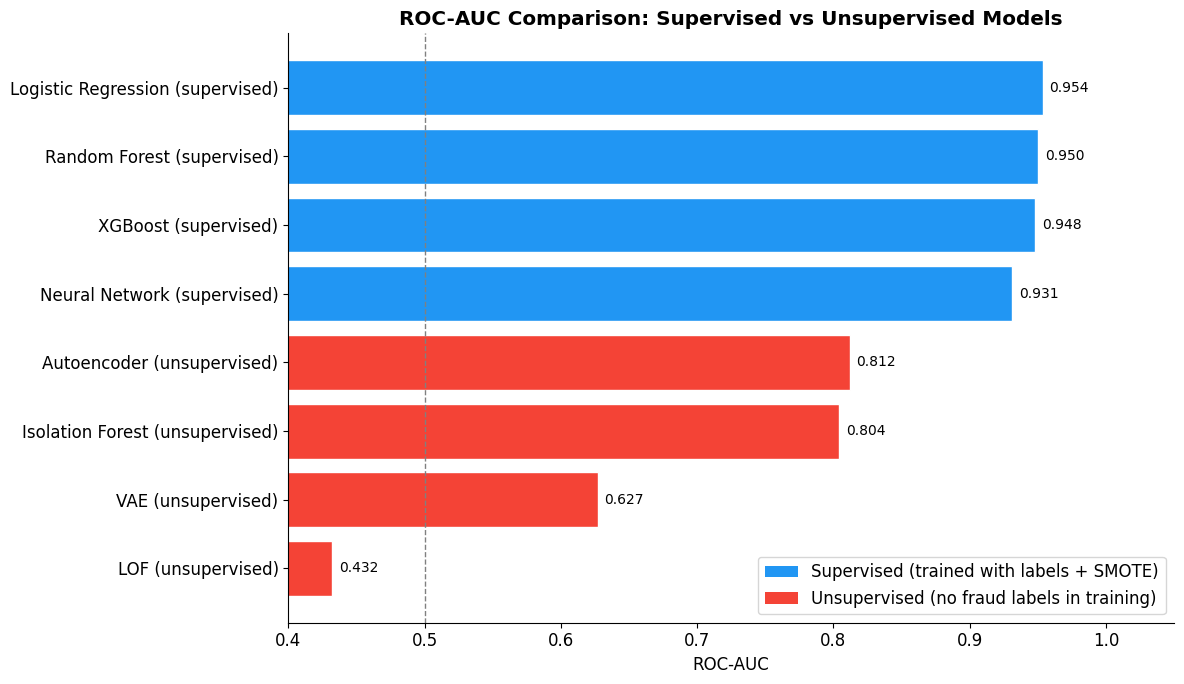


Key finding: supervised models have access to labeled fraud during training.
The gap between supervised and unsupervised quantifies the value of labeled data.


In [ ]:
# Manually enter the bootstrap CI results from the unsupervised notebook
unsupervised_results = {
    'Autoencoder (unsupervised)':      0.812,
    'Isolation Forest (unsupervised)': 0.804,
    'VAE (unsupervised)':              0.627,
    'LOF (unsupervised)':              0.432,
}

supervised_results = {
    name: roc_auc_score(y_test, prob)
    for name, prob in all_probs.items()
}

all_models = {**{k + ' (supervised)': v for k,v in supervised_results.items()},
              **unsupervised_results}
all_models_sorted = dict(sorted(all_models.items(), key=lambda x: x[1], reverse=True))

fig, ax = plt.subplots(figsize=(12, 7))
bar_colors = ['#2196F3' if 'supervised' in k and 'unsupervised' not in k
              else '#F44336' for k in all_models_sorted.keys()]
bars = ax.barh(list(all_models_sorted.keys()),
               list(all_models_sorted.values()),
               color=bar_colors, edgecolor='white')

for bar, val in zip(bars, all_models_sorted.values()):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=10)

ax.axvline(0.5, color='gray', linestyle='--', linewidth=1, label='Random baseline')
ax.set_xlabel('ROC-AUC')
ax.set_title('ROC-AUC Comparison: Supervised vs Unsupervised Models',
             fontweight='bold')
ax.set_xlim(0.4, 1.05)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2196F3', label='Supervised (trained with labels + SMOTE)'),
    Patch(facecolor='#F44336', label='Unsupervised (no fraud labels in training)')
]
ax.legend(handles=legend_elements, loc='lower right')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('supervised_vs_unsupervised.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nKey finding: supervised models have access to labeled fraud during training.')
print('The gap between supervised and unsupervised quantifies the value of labeled data.')

**Comments:** The supervised models cluster tightly between 0.931 and 0.954, a span of only 0.023 AUC points. The unsupervised models span a much wider range from 0.432 (LOF) to 0.812 (Autoencoder). The gap between the best unsupervised method (Autoencoder at 0.812) and the worst supervised method (Neural Network at 0.931) is about 0.12 AUC points — meaningful but not enormous. Knowing what fraud looks like is worth roughly 12–14 AUC points on this dataset. The most nuanced finding is that the unsupervised Autoencoder and Isolation Forest recover a substantial fraction of supervised performance without ever seeing a single labeled fraud example during training. For a healthcare system deploying fraud detection for the first time — before any fraud has been investigated and confirmed — the unsupervised approach delivers approximately 85% of the discrimination ceiling on day one. The supervised approach represents the ceiling you can reach once you've accumulated labeled fraud examples. The two approaches are best understood as sequential stages of the same deployment lifecycle rather than competing alternatives.

## 15. Save Artifacts

In [ ]:
comparison_df.to_csv('supervised_comparison.csv')
roi_df.to_csv('supervised_roi.csv', index=False)

# Save test set with all model predictions
test_results = provider_agg.iloc[X_test_raw.index].copy()[['Provider','FraudLabel','TotalReimbursed']]
for name, prob in all_probs.items():
    safe_name = name.replace(' ', '_')
    test_results[f'{safe_name}_prob']  = prob
    test_results[f'{safe_name}_pred']  = all_preds[name]
test_results.to_csv('supervised_test_predictions.csv', index=False)

print('Saved:')
print(' - supervised_comparison.csv')
print(' - supervised_roi.csv')
print(' - supervised_test_predictions.csv')
print(' - supervised_bootstrap_ci.csv')

Saved:
 - supervised_comparison.csv
 - supervised_roi.csv
 - supervised_test_predictions.csv
 - supervised_bootstrap_ci.csv


# Summary of Findings

This notebook complements the unsupervised analysis by training four supervised classifiers on labeled fraud data, with SMOTE used to address the 9.4% class imbalance. The central question is: how much better can we do when labeled fraud examples are available for training, rather than only at evaluation time?

**What worked and why.** All four supervised models cluster tightly between ROC-AUC 0.931 and 0.954 on the held-out test set, indicating that the fraud signal in these 40 provider-level features is strong enough that even simple models can exploit it effectively once labels are available. **Logistic Regression** achieved the highest ROC-AUC at 0.953 [0.936, 0.968], a striking result for the simplest method tested — this tells us the fraud signal in this dataset is largely linearly separable in the engineered feature space. **XGBoost** achieved the best operational performance with an F1 of 0.667 and the highest precision at 0.639, making it the best choice when investigator capacity is limited and false positives are costly. **Random Forest** sits between the two with a balance of precision (0.558) and recall (0.724). The **Neural Network** finished last at ROC-AUC 0.931 but with very competitive precision (0.614) and F1 (0.642) — still excellent in absolute terms and consistent with the established result that tree-based methods outperform neural networks on small-to-medium tabular datasets.

**Why model choice depends on the operational question.** The four models differ less in their ranking ability (all 0.93–0.95 AUC) than in where they sit on the precision-recall tradeoff. Logistic Regression catches 86% of fraudulent providers but flags roughly one legitimate provider for every fraud caught. XGBoost catches 70% of fraud with precision near 64% — less than half as many false positives but with seven fewer true positives per hundred. In a fraud investigation context where investigator time is the binding constraint, XGBoost is the right choice. Where missing fraud is more costly than wasted investigation, Logistic Regression is preferable. The choice is not technical, it's operational.

**The value of labeled data.** The supervised models outperform the best unsupervised model (Autoencoder, ROC-AUC 0.812) by roughly 0.12–0.14 AUC points. This is the quantified value of having confirmed fraud labels: meaningful, but not enormous. Crucially, the unsupervised Autoencoder recovers approximately 85% of the discrimination ceiling without ever seeing a labeled fraud example during training. For a health system or insurer deploying fraud detection for the first time — before any fraud has been investigated and confirmed — the unsupervised approach provides a strong starting point and a way to bootstrap the labels needed to eventually train supervised models. The two approaches are not competitors but stages of the same deployment lifecycle.

**Methodological rigor.** Both notebooks use the same stratified 70/30 train/test split with `random_state=42`, so the test set is the same 1,623 providers in both, and supervised-vs-unsupervised comparisons are directly comparable on a per-provider basis. SMOTE is applied only to the supervised training set, never to the test set, so test-set metrics reflect performance on the true 9.4% fraud distribution rather than the balanced training distribution. Bootstrap confidence intervals (500 iterations) are reported for all AUC values to characterize estimation uncertainty.

**Financial impact.** Logistic Regression recovers the most money in absolute terms on the test set ($101.9M) due to its high recall, but it does so by flagging 143 false positives at $1,000 each. XGBoost recovers $96.0M with only 60 false positives — less recoverable amount but less than half the investigation cost. At all three investigation cost scenarios tested ($500, $1,000, $2,000 per provider), all four supervised models remain massively net-positive, with investigation costs representing less than 0.3% of recoverable amounts. As in the unsupervised analysis, the dominant factor in net ROI is detection accuracy, not false-positive cost. Scaled to the full population (× 3.33), Logistic Regression's recoverable amount approaches **~$340M** and XGBoost's approaches **~$320M**.

**Limitations.** The dataset contains 5,410 providers from a single Medicare program in a single year. Generalization to other payer programs, other time periods, or other healthcare systems would require retraining. The fraud labels are "potential fraud" as identified by the dataset creators, not adjudicated convictions, so the labels themselves carry some uncertainty. SMOTE generates synthetic fraud examples by interpolation, which is appropriate for tabular data but cannot create new fraud patterns the model hasn't already seen — meaning supervised methods will tend to detect fraud that resembles historical fraud and may miss novel schemes that unsupervised anomaly detection would catch.

**Conclusion.** Supervised methods with labeled data set a ceiling around 0.95 ROC-AUC on this fraud detection problem. Unsupervised methods recover approximately 85% of that ceiling without any labels. The best deployment strategy is sequential: unsupervised models on day one to surface initial fraud candidates for investigation, supervised models trained on the resulting confirmed labels thereafter. Across both regimes, the financial case is overwhelmingly net-positive.